In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


In [2]:
class ImageDataset(Dataset):
    def __init__(self, root_dir):
        self.paths = []
        for folder in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, folder)
            for file in os.listdir(folder_path):
                if file.endswith('.png'):
                    self.paths.append(os.path.join(folder_path, file))

        self.transform = transforms.Compose([
            transforms.Resize((128,128)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img

In [ ]:
class CAE(nn.Module):
    def __init__(self, latent_channels):
        super(CAE, self).__init__()

        # Encoder: 128 → 64 → 32 → 16
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, latent_channels, 3, 2, 1),
            nn.BatchNorm2d(latent_channels),
            nn.ReLU()
        )

        # Decoder: 16 → 32 → 64 → 128
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 64, 3, 2, 1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon, latent

In [4]:
def denormalize(x):
    return (x * 0.5) + 0.5


def psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2)
    return 10 * torch.log10(1.0 / (mse + 1e-8))


def ssim(img1, img2):
    C1 = 0.01**2
    C2 = 0.03**2

    mu1 = img1.mean()
    mu2 = img2.mean()

    sigma1 = img1.var()
    sigma2 = img2.var()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()

    return ((2*mu1*mu2 + C1)*(2*sigma12 + C2)) / ((mu1**2 + mu2**2 + C1)*(sigma1 + sigma2 + C2))


def sam(img1, img2):
    img1 = img1.view(-1, 3)
    img2 = img2.view(-1, 3)

    dot = (img1 * img2).sum(dim=1)
    norm1 = torch.norm(img1, dim=1)
    norm2 = torch.norm(img2, dim=1)

    cos_theta = dot / (norm1 * norm2 + 1e-8)
    cos_theta = torch.clamp(cos_theta, -1, 1)  # FIX

    return torch.mean(torch.acos(cos_theta))

In [5]:
def train(model, loader, epochs=30):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    mse_loss = nn.MSELoss()
    l1_loss = nn.L1Loss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for img in loader:
            optimizer.zero_grad()

            recon, _ = model(img)

            loss = 0.8*mse_loss(recon, img) + 0.2*l1_loss(recon, img)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")


In [6]:
def show_results(models, sample):
    plt.figure(figsize=(12,4))

    sample_dn = denormalize(sample)

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(sample_dn.permute(1,2,0).cpu())
    plt.axis('off')

    for i, model in enumerate(models):
        model.eval()
        with torch.no_grad():
            recon, _ = model(sample.unsqueeze(0))
            recon = denormalize(recon.squeeze(0))

        plt.subplot(1,4,i+2)
        plt.title(f"Latent {latent_sizes[i]}")
        plt.imshow(recon.permute(1,2,0).cpu())
        plt.axis('off')

    plt.show()

In [7]:
root_dir = r"F:\work\python\image frequency\landsat\land7_cate"
dataset = ImageDataset(root_dir)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

latent_sizes = [64, 96, 128]
models = []

for size in latent_sizes:
    print(f"\nTraining model with latent size: {size}")
    model = CAE(size)
    train(model, loader, epochs=20)
    models.append(model)


Training model with latent size: 64
Epoch 1, Loss: 0.0534
Epoch 2, Loss: 0.0093
Epoch 3, Loss: 0.0080
Epoch 4, Loss: 0.0070
Epoch 5, Loss: 0.0060
Epoch 6, Loss: 0.0055
Epoch 7, Loss: 0.0050
Epoch 8, Loss: 0.0048
Epoch 9, Loss: 0.0047
Epoch 10, Loss: 0.0045
Epoch 11, Loss: 0.0042
Epoch 12, Loss: 0.0043
Epoch 13, Loss: 0.0042
Epoch 14, Loss: 0.0039
Epoch 15, Loss: 0.0040
Epoch 16, Loss: 0.0038
Epoch 17, Loss: 0.0037
Epoch 18, Loss: 0.0036
Epoch 19, Loss: 0.0037
Epoch 20, Loss: 0.0035

Training model with latent size: 96
Epoch 1, Loss: 0.0594
Epoch 2, Loss: 0.0091
Epoch 3, Loss: 0.0075
Epoch 4, Loss: 0.0062
Epoch 5, Loss: 0.0058
Epoch 6, Loss: 0.0051
Epoch 7, Loss: 0.0048
Epoch 8, Loss: 0.0046
Epoch 9, Loss: 0.0043
Epoch 10, Loss: 0.0044
Epoch 11, Loss: 0.0041
Epoch 12, Loss: 0.0041
Epoch 13, Loss: 0.0042
Epoch 14, Loss: 0.0037
Epoch 15, Loss: 0.0042
Epoch 16, Loss: 0.0037
Epoch 17, Loss: 0.0035
Epoch 18, Loss: 0.0032
Epoch 19, Loss: 0.0034
Epoch 20, Loss: 0.0033

Training model with lat


Latent Size: 64
PSNR: 26.29827117919922
SSIM: 0.9879324436187744
SAM: 0.04481624439358711
Compression Ratio: 3.0

Latent Size: 96
PSNR: 24.919797897338867
SSIM: 0.9833465218544006
SAM: 0.043921392410993576
Compression Ratio: 2.0

Latent Size: 128
PSNR: 27.171213150024414
SSIM: 0.9903335571289062
SAM: 0.04437003284692764
Compression Ratio: 1.5


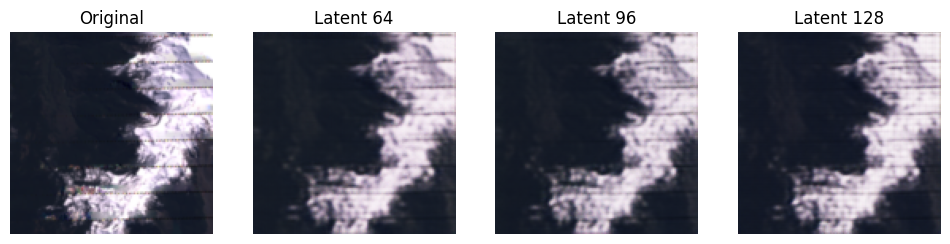

In [ ]:
sample = dataset[0]

for i, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        recon, latent = model(sample.unsqueeze(0))
        recon = recon.squeeze(0)

    img_dn = denormalize(sample)
    recon_dn = denormalize(recon)

    print(f"\nLatent Size: {latent_sizes[i]}")
    print("PSNR:", psnr(img_dn, recon_dn).item())
    print("SSIM:", ssim(img_dn, recon_dn).item())
    print("SAM:", sam(img_dn, recon_dn).item())
    print("Compression Ratio:", sample.numel() / latent.numel())


show_results(models, sample)



In [9]:
root_dir = r"F:\work\python\image frequency\landsat\land7_cate"
dataset = ImageDataset(root_dir)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

latent_sizes = [64, 96, 128]
models = []

for size in latent_sizes:
    print(f"\nTraining model with latent size: {size}")
    model = CAE(size)
    train(model, loader, epochs=30)
    models.append(model)


Training model with latent size: 64
Epoch 1, Loss: 0.0509
Epoch 2, Loss: 0.0095
Epoch 3, Loss: 0.0073
Epoch 4, Loss: 0.0066
Epoch 5, Loss: 0.0062
Epoch 6, Loss: 0.0054
Epoch 7, Loss: 0.0056
Epoch 8, Loss: 0.0061
Epoch 9, Loss: 0.0046
Epoch 10, Loss: 0.0044
Epoch 11, Loss: 0.0045
Epoch 12, Loss: 0.0043
Epoch 13, Loss: 0.0041
Epoch 14, Loss: 0.0039
Epoch 15, Loss: 0.0036
Epoch 16, Loss: 0.0037
Epoch 17, Loss: 0.0039
Epoch 18, Loss: 0.0037
Epoch 19, Loss: 0.0037
Epoch 20, Loss: 0.0034
Epoch 21, Loss: 0.0036
Epoch 22, Loss: 0.0035
Epoch 23, Loss: 0.0034
Epoch 24, Loss: 0.0032
Epoch 25, Loss: 0.0035
Epoch 26, Loss: 0.0036
Epoch 27, Loss: 0.0033
Epoch 28, Loss: 0.0033
Epoch 29, Loss: 0.0029
Epoch 30, Loss: 0.0029

Training model with latent size: 96
Epoch 1, Loss: 0.0476
Epoch 2, Loss: 0.0122
Epoch 3, Loss: 0.0085
Epoch 4, Loss: 0.0063
Epoch 5, Loss: 0.0058
Epoch 6, Loss: 0.0051
Epoch 7, Loss: 0.0052
Epoch 8, Loss: 0.0046
Epoch 9, Loss: 0.0048
Epoch 10, Loss: 0.0048
Epoch 11, Loss: 0.0043
E


Latent Size: 64
PSNR: 28.388408660888672
SSIM: 0.9927927255630493
SAM: 0.04254430532455444
Compression Ratio: 3.0

Latent Size: 96
PSNR: 28.895000457763672
SSIM: 0.9935451149940491
SAM: 0.04027429223060608
Compression Ratio: 2.0

Latent Size: 128
PSNR: 29.263086318969727
SSIM: 0.9941324591636658
SAM: 0.039398107677698135
Compression Ratio: 1.5


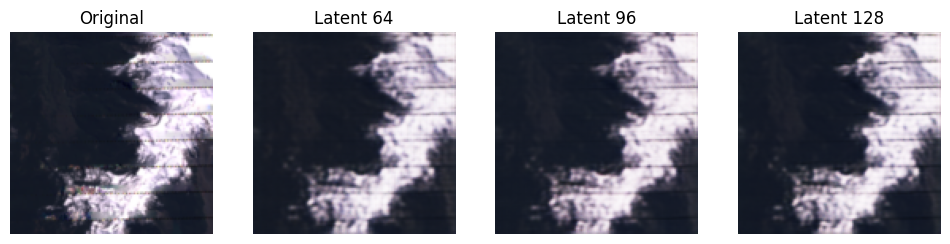

In [ ]:
sample = dataset[0]

for i, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        recon, latent = model(sample.unsqueeze(0))
        recon = recon.squeeze(0)

    img_dn = denormalize(sample)
    recon_dn = denormalize(recon)

    print(f"\nLatent Size: {latent_sizes[i]}")
    print("PSNR:", psnr(img_dn, recon_dn).item())
    print("SSIM:", ssim(img_dn, recon_dn).item())
    print("SAM:", sam(img_dn, recon_dn).item())
    print("Compression Ratio:", sample.numel() / latent.numel())


show_results(models, sample)

In [11]:
def test_specific_images(image_paths, models, latent_sizes):
    import matplotlib.pyplot as plt

    def denorm(x):
        return (x * 0.5) + 0.5

    transform = transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    for img_path in image_paths:
        print(f"\n===== Testing: {img_path} =====")

        img = Image.open(img_path).convert("RGB")
        img_tensor = transform(img)

        plt.figure(figsize=(12,4))

        # Original
        plt.subplot(1, len(models)+1, 1)
        plt.title("Original")
        plt.imshow(denorm(img_tensor).permute(1,2,0))
        plt.axis('off')

        img_dn = denorm(img_tensor)

        for i, model in enumerate(models):
            model.eval()
            with torch.no_grad():
                recon, latent = model(img_tensor.unsqueeze(0))
                recon = recon.squeeze(0)

            recon_dn = denorm(recon)

            # Metrics
            print(f"\nLatent Size: {latent_sizes[i]}")
            print("PSNR:", psnr(img_dn, recon_dn).item())
            print("SSIM:", ssim(img_dn, recon_dn).item())
            print("SAM:", sam(img_dn, recon_dn).item())
            print("Compression Ratio:", img_tensor.numel() / latent.numel())

            # Plot
            plt.subplot(1, len(models)+1, i+2)
            plt.title(f"L{latent_sizes[i]}")
            plt.imshow(recon_dn.permute(1,2,0))
            plt.axis('off')

        plt.show()

In [17]:
low_img = r"F:\work\python\image frequency\landsat\land7_cate\low\patch_14.png"
medium_img = r"F:\work\python\image frequency\landsat\land7_cate\medium\patch_40.png"
high_img = r"F:\work\python\image frequency\landsat\land7_cate\high\patch_1003.png"


===== Testing: F:\work\python\image frequency\landsat\land7_cate\low\patch_14.png =====

Latent Size: 64
PSNR: 43.624996185302734
SSIM: 0.9839519262313843
SAM: 0.022495092824101448
Compression Ratio: 3.0

Latent Size: 96
PSNR: 44.3046875
SSIM: 0.9903040528297424
SAM: 0.020311027765274048
Compression Ratio: 2.0

Latent Size: 128
PSNR: 45.590049743652344
SSIM: 0.9908643364906311
SAM: 0.019405608996748924
Compression Ratio: 1.5


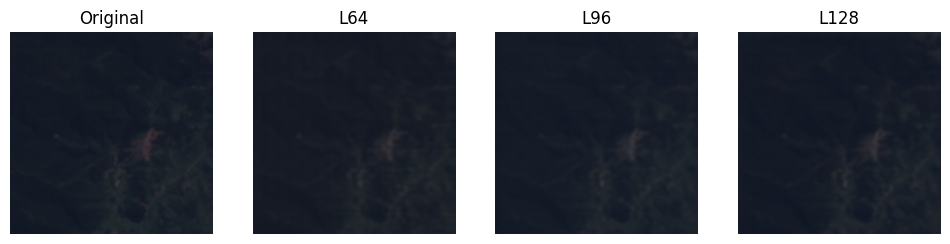


===== Testing: F:\work\python\image frequency\landsat\land7_cate\medium\patch_40.png =====

Latent Size: 64
PSNR: 35.32627487182617
SSIM: 0.9909092783927917
SAM: 0.025805028155446053
Compression Ratio: 3.0

Latent Size: 96
PSNR: 36.01087188720703
SSIM: 0.9924513101577759
SAM: 0.024070722982287407
Compression Ratio: 2.0

Latent Size: 128
PSNR: 36.455963134765625
SSIM: 0.9932068586349487
SAM: 0.0232381634414196
Compression Ratio: 1.5


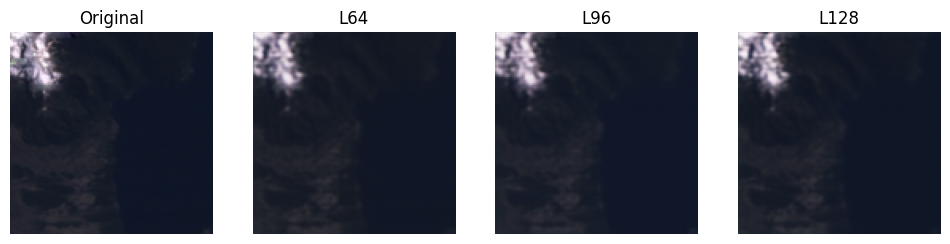


===== Testing: F:\work\python\image frequency\landsat\land7_cate\high\patch_1003.png =====

Latent Size: 64
PSNR: 28.388408660888672
SSIM: 0.9927927255630493
SAM: 0.04254430532455444
Compression Ratio: 3.0

Latent Size: 96
PSNR: 28.895000457763672
SSIM: 0.9935451149940491
SAM: 0.04027429223060608
Compression Ratio: 2.0

Latent Size: 128
PSNR: 29.263086318969727
SSIM: 0.9941324591636658
SAM: 0.039398107677698135
Compression Ratio: 1.5


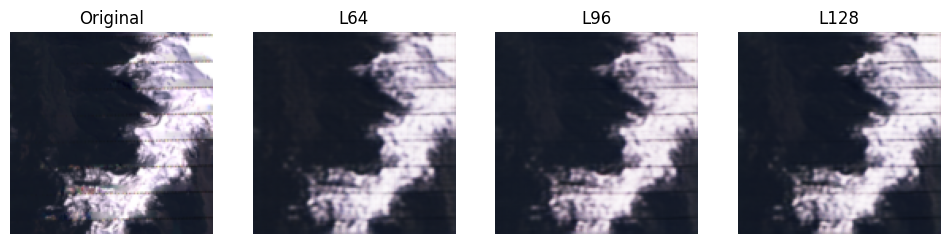

In [18]:
test_images = [low_img, medium_img, high_img]
test_specific_images(test_images, models, latent_sizes)